# **Linear Regression from Scratch**
#### By Iliyas Shaizada (1l1ss)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

path = 'StudentPerformanceFactors.csv'

## Data preparation

In [2]:
dataset = pd.read_csv(path)
dataset.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
dataset

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [4]:
# Data for fitting the model, there is only 1 feature selected for the sake of later visualisation of results
X_vals = np.asarray(dataset['Hours_Studied']).reshape(-1,1) 
y_vals = np.asarray(dataset['Exam_Score']).reshape(-1)

X_train, X_test, y_train, y_test = train_test_split(X_vals, y_vals)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4955, 1) (1652, 1) (4955,) (1652,)


## Implementation of a model (Batch Gradient Descent)

#### Basic OLS with Batch Gradient Descent, it follows the method of basic Gradient Descent, updating weights each time by subtracting the Gradient of the Loss function of OLS multiplied by the learning rate "$\alpha$". Formula following: $\Theta_j:=\Theta_j-\alpha\frac{1}{m}\sum_{i=1}^{m}(h_\Theta(x^{(i)})-y^{(i)})x_j^{(i)}$, where $\Theta$ stands for parameters and $h_{\Theta}$ for original hypothesis: $\sum^n_{j=0}\Theta_jx_j$, where $x_0-1$

In [5]:
class LinearRegressionBGD:
    def __init__(self, learning_rate=0.001):
        self.learning_rate = learning_rate
        self.weights = None 

    def fit(self, X_values, y_target, epochs):
        n_s = X_values.shape[0]
        bias = np.ones((n_s, 1)) # An array of ones matching the number of samples for quicker computation of bias through: x_0=1
        X = np.hstack((bias, X_values))

        if self.weights is None:
            self.weights = np.zeros(X.shape[1]) # Initializes weights to 0
            
        for _ in range(epochs):                     
            gradient = -(2 / n_s) * (X.T @ (y_target - X @ self.weights)) # Computation of a gradient provided above  
            self.weights -= self.learning_rate * gradient # Update of the weights

    def predict(self, X_values):
        n_s = X_values.shape[0]
        bias = np.ones((n_s, 1))
        X = np.hstack((bias, X_values))
        return X @ self.weights

    def show_weights(self): # For further visualisation and a small sanity check
        return self.weights 

In [6]:
A = LinearRegressionBGD()
A.fit(X_train, y_train, 100000)
A

In [7]:
A.show_weights()

array([61.43556907,  0.29085509])

In [8]:
A.predict(X_test)

array([66.96181571, 68.12523606, 66.96181571, ..., 66.38010554,
       65.21668519, 63.47155467], shape=(1652,))

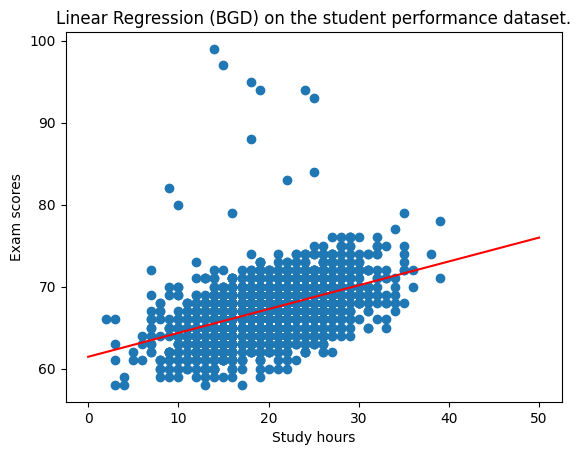

In [9]:
plt.title('Linear Regression (BGD) on the student performance dataset.')
plt.xlabel('Study hours')
plt.ylabel('Exam scores')
plt.scatter(X_test, y_test)
c, w = A.show_weights()
line = w*np.linspace(0, 50)+c
plt.plot(np.linspace(0, 50), line, 'r')
plt.show()

## Implementation of a model (Closed-form)

#### Basic OLS with Closed-Form Solution, unlike Gradient Descent, it directly computes the optimal weights by minimizing the OLS Loss function analytically, instead of iteratively updating them as in Gradient Descent. The solution is given by the Normal Equation: $\Theta = (X^TX)^-1X^Ty$, where $\Theta$ stands for parameters, $X$ for the design matrix (with first column $x_1 =1$ for the bias term), and y is a target vector.

In [10]:
class LinearRegressionCF:
    def __init__(self):
        self.weights = None 

    def fit(self, X_values, y_target):
        n_s = X_values.shape[0]
        bias = np.ones((n_s, 1))
        X = np.hstack((bias, X_values))

        self.weights = (np.linalg.inv(X.T@X) @ X.T @ y_target) # Computed directly through the Normal Equation

    def predict(self, X_values):
        n_s = X_values.shape[0]
        bias = np.ones((n_s, 1))
        X = np.hstack((bias, X_values))
        return X @ self.weights

    def show_weights(self):
        return self.weights

In [11]:
B = LinearRegressionCF()
B.fit(X_train, y_train)
B

In [12]:
B.show_weights()

array([61.43557228,  0.29085494])

In [13]:
B.predict(X_test)

array([66.96181612, 68.12523588, 66.96181612, ..., 66.38010624,
       65.21668649, 63.47155685], shape=(1652,))

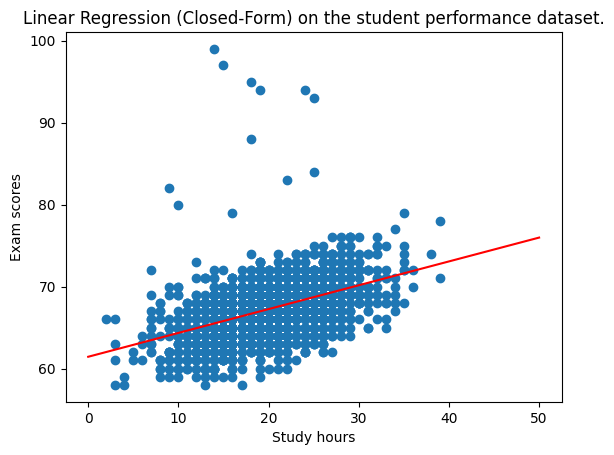

In [14]:
plt.title('Linear Regression (Closed-Form) on the student performance dataset.')
plt.xlabel('Study hours')
plt.ylabel('Exam scores')
plt.scatter(X_test, y_test)
c, w = A.show_weights()
line = w*np.linspace(0, 50)+c
plt.plot(np.linspace(0, 50), line, 'r')
plt.show()